In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv

In [2]:
load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id='deepseek-ai/DeepSeek-V3.2-Exp',
    task='text-generation'
)

model= ChatHuggingFace(llm=llm)

In [13]:
class LLMState(TypedDict):
    topic: str
    outline: str
    content: str
    evaluation: str

In [5]:
def gen_outline(state: LLMState) -> LLMState:
    
    # extract topic
    topic = state['topic']
    
    # form a prompt
    prompt = f"Generate a blog outline for this topic: {topic}"
    
    # generate outline
    outline = model.invoke(prompt).content
    state['outline'] = outline
    
    # return state
    return state

In [6]:
def gen_content(state: LLMState) -> LLMState:
    # extract topic
    topic = state['topic']
    # extract outline
    outline = state['outline']
    
    # form a prompt 
    prompt = f"For the topic {topic}, using the outline below, form a blog content.\n Outline: {outline}"
    
    # generate content
    content = model.invoke(prompt).content
    state['content'] = content
    
    return state

In [14]:
def evaluate_blog(state: LLMState) -> LLMState:
    # extract topic
    topic = state['topic']
    # extract outline
    outline = state['outline']
    # extract content
    content = state['content']
    
    # form a prompt 
    prompt = f"Based on the given outline, for this topic ({topic}), rate my blog. \n\n Outline: {outline}"
    
    # generate content
    evaluation = model.invoke(prompt).content
    state['evaluation'] = evaluation
    
    return state

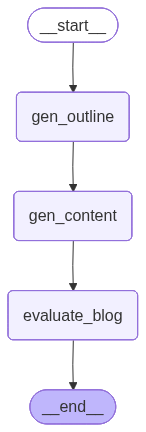

In [16]:
# create a graph

graph = StateGraph(LLMState)

# add nodes
graph.add_node('gen_outline', gen_outline)
graph.add_node('gen_content', gen_content)
graph.add_node('evaluate_blog', evaluate_blog)

# add edges
graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_content')
graph.add_edge('gen_content', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

# compile
workflow = graph.compile()
workflow

In [17]:
# execute
final_state = workflow.invoke({"topic": "Universe"})
final_state

{'topic': 'Universe',
 'outline': 'Of course! Here is a comprehensive blog outline for the topic of "Universe," designed to take the reader on a journey from the very small to the unimaginably vast, while weaving in wonder and scientific discovery.\n\n---\n\n### **Blog Title:** The Universe: A Beginner\'s Guide to Everything That Exists\n\n**Target Audience:** Curious minds with little to no scientific background; anyone who has ever looked up at the night sky and wondered.\n\n**Blog Tone:** Awe-inspiring, clear, conversational, and thought-provoking.\n\n---\n\n### **Blog Outline**\n\n**Introduction: Your Place in the Cosmos**\n*   **Hook:** Start with a powerful, relatable question. "Have you ever felt small looking up at a star-filled sky? You should. But you should also feel incredible, because you are a part of that vastness."\n*   **Thesis:** This blog is a journey to understand the universe—what it is, how it began, what it\'s made of, and the profound mysteries that still remain

In [10]:
print(final_state['outline'])

Of course! Here is a comprehensive blog outline for the topic "Universe," designed to take a reader on a journey from the familiar to the profoundly mysterious. This structure is modular, so you can expand or condense sections as needed.

---

### **Blog Title Ideas:**
*   The Universe: A Beginner's Guide to Everything That Exists
*   From the Big Bang to Black Holes: Unraveling the Cosmos
*   Our Place in the Cosmos: A Journey Through the Universe
*   The Universe: 10 Mind-Bending Facts That Will Change Your Perspective

### **Target Audience:**
Curious individuals with a casual to moderate interest in science, looking for an engaging and understandable overview of cosmology and astronomy.

---

### **Blog Outline: The Universe**

#### **Introduction: Your Cosmic Address**
*   **Hook:** Start with a relatable perspective. "Look up at the night sky. Every star, every faint speck of light, exists within a single, vast system we call the Universe. But what is it, really?"
*   **The "What

In [11]:
print(final_state['content'])

Of course! Here is a full blog post crafted from your comprehensive outline, designed to be engaging, informative, and awe-inspiring for the curious reader.

---

### **Blog Title: The Universe: A Beginner's Guide to Everything That Exists**

#### **Introduction: Your Cosmic Address**

Look up at the night sky. Every star, every faint speck of light, exists within a single, vast system we call the Universe. It’s a word we use casually, but what is it, really? In its simplest terms, the Universe is the sum total of all that exists—all of space, time, matter, and energy, from the tiniest subatomic particle to the largest galaxy cluster.

It can feel overwhelming, but don't worry. Consider this your personal guided tour of the cosmos. We’ll journey from its explosive beginning to its mysterious future, exploring the fundamental forces that shape it and our unique, tiny place within it. Let's begin.

---

### **Part 1: The Beginning - The Big Bang**

The story of our Universe starts with t

In [21]:
print(final_state['evaluation'])

This is an exceptional blog outline. It's clear, comprehensive, and perfectly tailored to your target audience. Here’s a detailed rating and analysis based on key criteria.

### Overall Rating: 9.5/10

This outline is a recipe for a highly successful, engaging, and informative blog post. It's in the top tier of science communication for a general audience.

---

### Breakdown of the Rating:

#### 1. Structure & Flow: 10/10
*   **Logical Progression:** The journey from the beginning (Big Bang) to the ingredients (cosmic composition) to the structures (galaxies, stars) and finally to the large-scale fate and unanswered questions is perfectly sequenced. It mimics how we naturally learn and build understanding.
*   **Narrative Arc:** It doesn't just present facts; it tells a story. It starts with a personal hook, builds through the epic history of the cosmos, and ends by bringing the reader back to their own place in it, leaving them with a sense of wonder and curiosity. This is masterful 